In [2]:
import sys

import numpy as np
from monodromy.haar import expected_cost
from gulps.viz.polytope_viz import _plot_coverage_set, _plot_polytope
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.core.invariants import GateInvariants
from weylchamber import WeylChamber, c1c2c3

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

ModuleNotFoundError: No module named 'docplex'

In [22]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

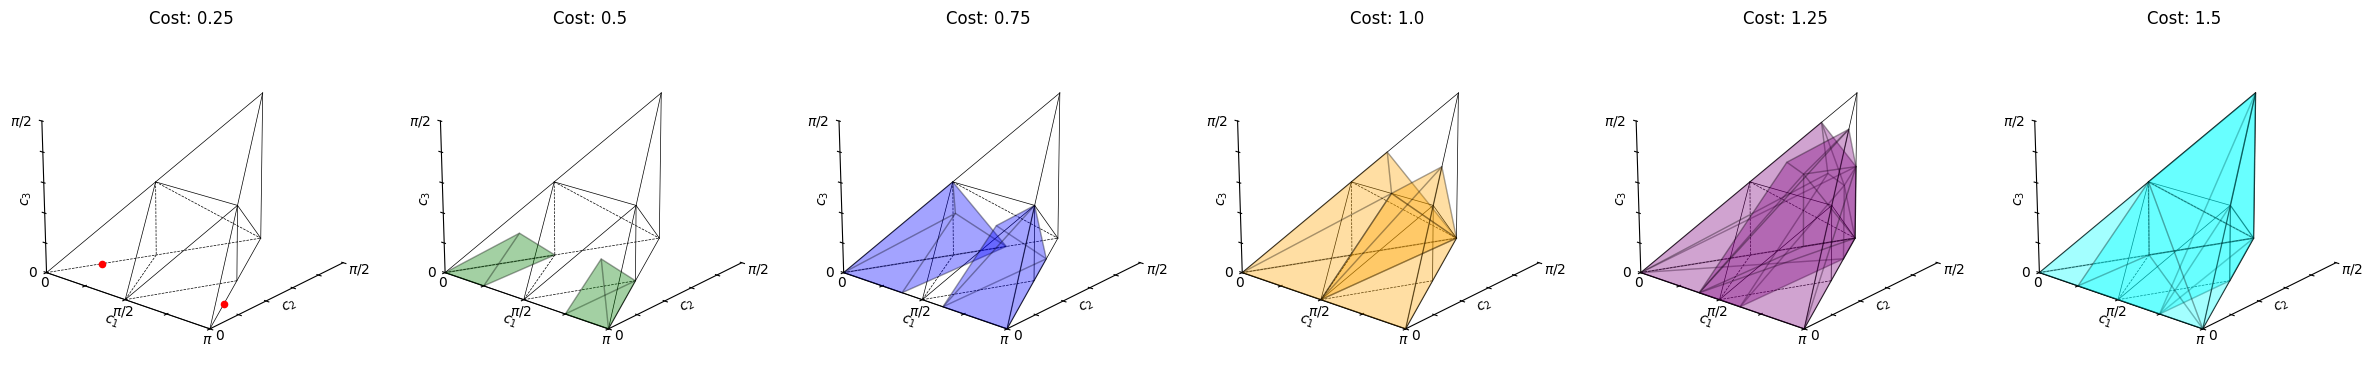

Expected cost (ground truth): 0.9598936659817361


In [23]:
# Ground truth expected cost from polytope volumes
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(f"Expected cost (ground truth): {expected_cost(decomposer.isa.coverage_set)}")

In [31]:
1.0975 / 0.9598936659817361

1.1433558100183172

In [24]:
# Step 2: Polytope lookup hit rate
N = 100
lookup_hit_rate = {}
found_targets = []

for idx in tqdm(range(N), desc="Polytope lookup"):
    u = random_unitary(4, seed=idx)
    target = GateInvariants.from_unitary(u, enforce_alcove=True)
    # target = bespoke_random(idx)
    sentence, rho_bool = decomposer.isa.polytope_lookup(target)

    if rho_bool:
        actual_target = target.rho_reflect
    else:
        actual_target = target

    if sentence is not None:
        found_targets.append((actual_target, sentence))
        lookup_hit_rate[tuple(sentence)] = lookup_hit_rate.get(tuple(sentence), 0) + 1

lookup_cost = (
    sum(
        sum(decomposer.isa.cost_dict[s] for s in sentence) * count
        for sentence, count in lookup_hit_rate.items()
    )
    / N
)
lookup_success_rate = sum(lookup_hit_rate.values()) / N

print(f"\nLookup hit rate: {lookup_success_rate}")
print(f"Empirical lookup cost: {lookup_cost}")

Polytope lookup:   0%|          | 0/100 [00:00<?, ?it/s]

Polytope lookup: 100%|██████████| 100/100 [00:00<00:00, 3313.72it/s]


Lookup hit rate: 1.0
Empirical lookup cost: 0.97


In [25]:
# Step 3: LP verification
from collections import defaultdict

lp_hit_rate = {}
lp_failures_by_len = defaultdict(list)

for target, sentence in tqdm(found_targets, desc="LP feasibility check"):
    sentence_out, _, _ = decomposer._try_lp(sentence, target)
    if sentence_out is None:
        lp_failures_by_len[len(sentence)].append(target)
    else:
        lp_hit_rate[tuple(sentence_out)] = lp_hit_rate.get(tuple(sentence_out), 0) + 1


lp_cost = (
    sum(
        sum(decomposer.isa.cost_dict[s] for s in sentence) * count
        for sentence, count in lp_hit_rate.items()
    )
    / N
)
lp_success_rate = sum(lp_hit_rate.values()) / N

print(f"\nLP hit rate: {lp_success_rate:.4f}")
print(f"Empirical LP cost: {lp_cost:.4f}")
print(f"LP disagreements: {len(lp_failures_by_len)} / {len(found_targets)}")

LP feasibility check:   0%|          | 0/100 [00:00<?, ?it/s]

LP feasibility check: 100%|██████████| 100/100 [00:00<00:00, 658.72it/s]


LP hit rate: 1.0000
Empirical LP cost: 0.9700
LP disagreements: 0 / 100


In [26]:
for depth, failures in sorted(lp_failures_by_len.items()):
    w = WeylChamber()
    for f in failures:
        w.add_point(*f.weyl)
    w.plot()

    # Optional: Overlay the corresponding polytope(s) for context
    if depth < len(decomposer.isa.coverage_set):
        _plot_polytope(decomposer.isa.coverage_set[depth], w)

In [27]:
# Step 4: Print sorted hit rate tables
def print_hit_table(label, table):
    print(f"\n{label} hitrate table:")
    for k, v in sorted(table.items(), key=lambda x: (len(x[0]), -x[1])):
        print(f"{len(k):2d}-gate: {v / N:.4f}   {'.'.join(g.name for g in k)}")


print_hit_table("Lookup", lookup_hit_rate)
print_hit_table("LP", lp_hit_rate)


Lookup hitrate table:
 2-gate: 0.0100   sqrt4iswap.sqrt4iswap
 3-gate: 0.1900   sqrt4iswap.sqrt4iswap.sqrt4iswap
 4-gate: 0.7100   sqrt4iswap.sqrt4iswap.sqrt4iswap.sqrt4iswap
 5-gate: 0.0900   sqrt4iswap.sqrt4iswap.sqrt4iswap.sqrt4iswap.sqrt4iswap

LP hitrate table:
 2-gate: 0.0100   sqrt4iswap.sqrt4iswap
 3-gate: 0.1900   sqrt4iswap.sqrt4iswap.sqrt4iswap
 4-gate: 0.7100   sqrt4iswap.sqrt4iswap.sqrt4iswap.sqrt4iswap
 5-gate: 0.0900   sqrt4iswap.sqrt4iswap.sqrt4iswap.sqrt4iswap.sqrt4iswap


In [28]:
# force a 2-gate case in the triangle
# # 0<=c1<=0.5, 0<=c2<=0.25, c3=0
# # c1 >= c2
# # randomly generate c1 and c2
# def bespoke_random(seed):
#     np.random.seed(seed)
#     r1 = np.random.uniform()

#     if r1 < 0.5:
#         # Triangle 1
#         A = np.array([1.0, 0.0])
#         B = np.array([0.5, 0.0])
#         C = np.array([0.75, 0.25])
#     else:
#         # Triangle 2
#         A = np.array([0.0, 0.0])
#         B = np.array([0.5, 0.0])
#         C = np.array([0.25, 0.25])

#     # Sample uniformly in triangle using barycentric method
#     u = np.random.uniform()
#     v = np.random.uniform()
#     if u + v > 1:
#         u = 1 - u
#         v = 1 - v

#     point = A + u * (B - A) + v * (C - A)
#     return GateInvariants.from_weyl(coords=(point[0], point[1], 0.0))